In [1]:
!pip install catboost shap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from catboost import CatBoostClassifier
import shap

import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

In [3]:
df = pd.read_csv(
    r"D:\My\00-Lectures-MSc\SEM 02\Machine Learning\Asignment\mobitel_customer_risk_dataset.csv",
    parse_dates=["package_start_date", "last_payment_date"]
)

today = pd.to_datetime("2025-01-01")
df.head()

,customer_id,plan_type,package_start_date,last_payment_date,monthly_bill,data_usage_gb,avg_call_minutes,complaints,tenure_months
0,100000,Prepaid,2022-01-31,2022-08-10,1717.0,91.3,263.0,0,35
1,100001,Prepaid,2022-12-30,2023-11-17,2674.0,120.6,1925.0,2,24
2,100002,Prepaid,2021-05-10,2021-05-20,5728.0,71.5,1674.0,1,44
3,100003,Prepaid,2022-07-18,2023-06-11,2478.0,64.6,1408.0,2,29
4,100004,Postpaid,2022-02-04,2022-04-09,1415.0,149.4,1837.0,0,35


In [4]:
df["days_since_last_payment"] = (today - df["last_payment_date"]).dt.days

df["usage_intensity"] = df["data_usage_gb"] / (df["tenure_months"] + 1)
df["complaint_rate"] = df["complaints"] / (df["tenure_months"] + 1)
df["bill_per_gb"] = df["monthly_bill"] / (df["data_usage_gb"] + 1)

df["plan_type"] = df["plan_type"].astype(str)

In [5]:
risk_score = (
    0.4 * (df["days_since_last_payment"] / df["days_since_last_payment"].max()) +
    0.3 * (df["complaint_rate"] / df["complaint_rate"].max()) +
    0.3 * (1 - (df["usage_intensity"] / df["usage_intensity"].max()))
)

df["risk_level"] = pd.qcut(
    risk_score,
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print(df["risk_level"].value_counts())

risk_level
Low Risk       1667
High Risk      1667
Medium Risk    1666
Name: count, dtype: int64


In [6]:
features = [
    "days_since_last_payment",
    "monthly_bill",
    "data_usage_gb",
    "avg_call_minutes",
    "complaint_rate",
    "bill_per_gb",
    "tenure_months",
    "plan_type"
]

X = df[features]
y = df["risk_level"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)


# TRAIN–TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.25,
    random_state=42,
    stratify=y_encoded
)

In [7]:
model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function="MultiClass",
    verbose=False
)

model.fit(
    X_train,
    y_train,
    cat_features=["plan_type"]
)

              precision    recall  f1-score   support

   High Risk       0.99      0.98      0.98       417
    Low Risk       0.99      0.97      0.98       417
 Medium Risk       0.96      0.98      0.97       416

    accuracy                           0.98      1250
   macro avg       0.98      0.98      0.98      1250
weighted avg       0.98      0.98      0.98      1250

ROC-AUC: 0.9987169235892107


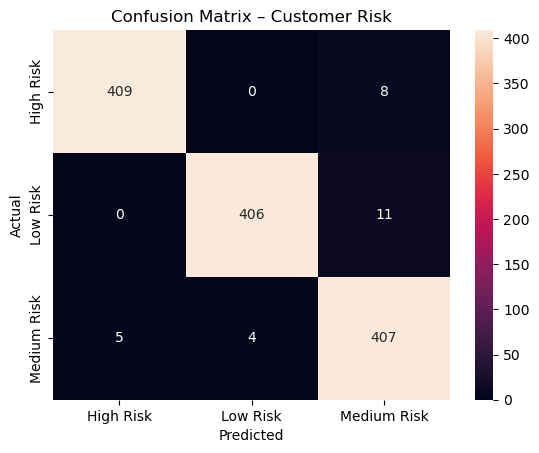

In [8]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))
print("ROC-AUC:", roc_auc_score(y_test, y_prob, multi_class="ovr"))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix – Customer Risk")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

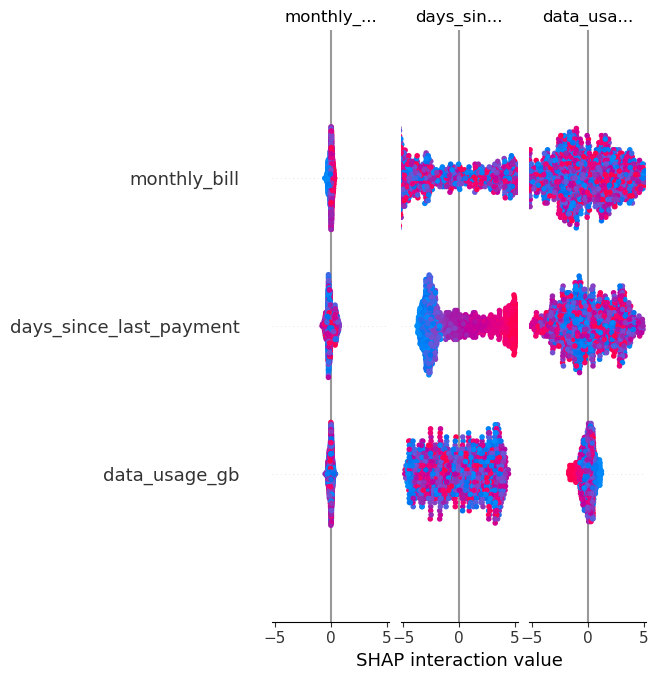

In [9]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)




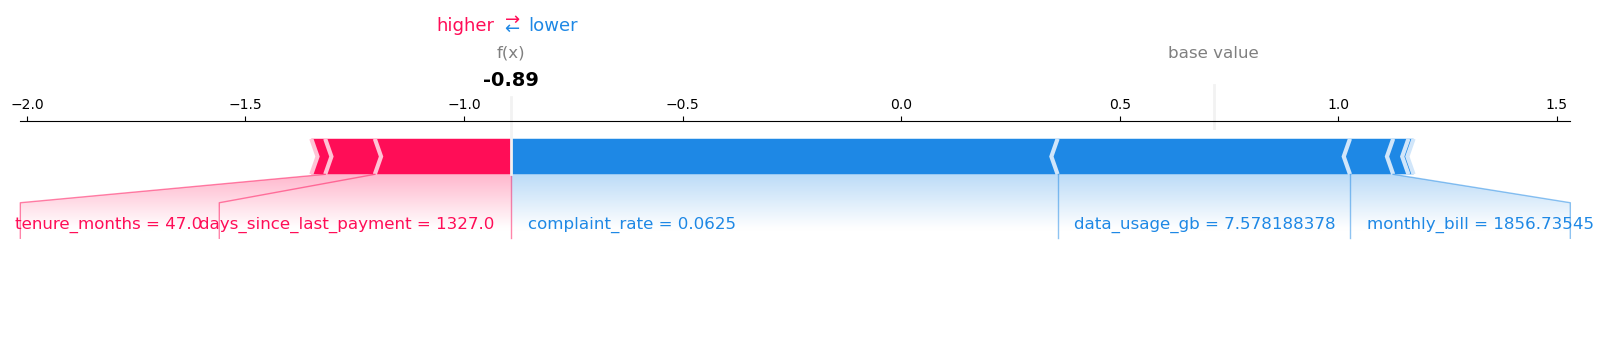

In [10]:
sample_index = 0
class_index = 2

shap.force_plot(
    explainer.expected_value[class_index],          # expected value for that class
    shap_values[sample_index, :, class_index],      # shap values for this sample and class
    X_test.iloc[sample_index],                      # feature values for this sample
    matplotlib=True
)


In [11]:
df["high_risk_probability"] = model.predict_proba(X)[:, 2]

df.to_csv(r"D:\My\00-Lectures-MSc\SEM 02\Machine Learning\Asignment\mobitel_dashboard_ready.csv", index=False)

print("Saved: mobitel_dashboard_ready.csv")

Saved: mobitel_dashboard_ready.csv


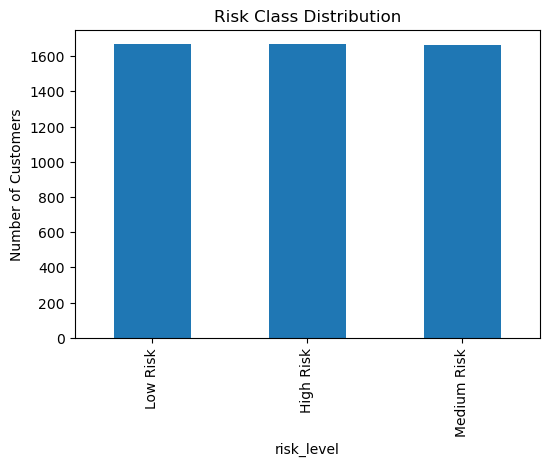

In [12]:
plt.figure(figsize=(6,4))
df["risk_level"].value_counts().plot(kind="bar")
plt.title("Risk Class Distribution")
plt.ylabel("Number of Customers")
plt.show()


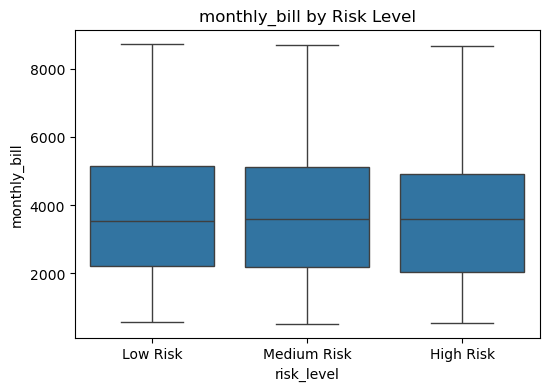

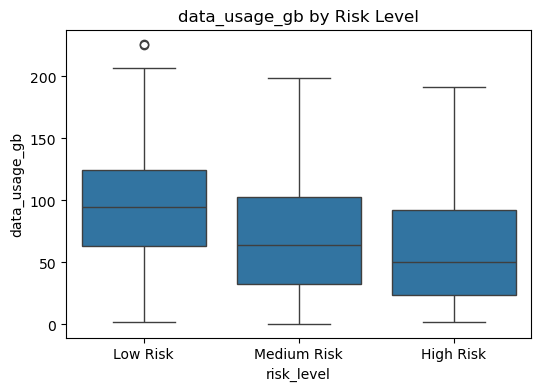

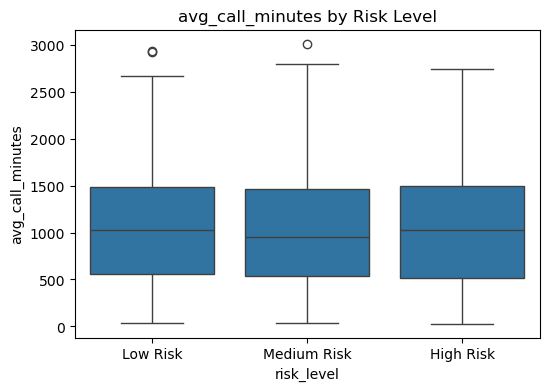

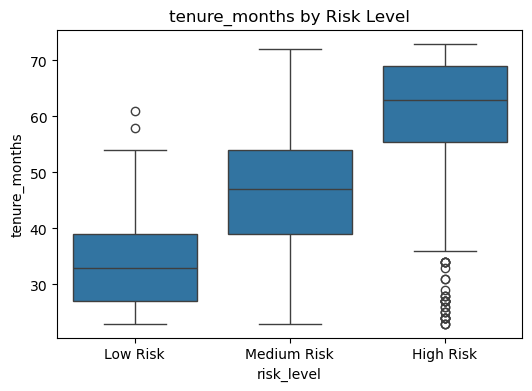

In [13]:
features_to_plot = [
    "monthly_bill",
    "data_usage_gb",
    "avg_call_minutes",
    "tenure_months"
]

for col in features_to_plot:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="risk_level", y=col, data=df,
                order=["Low Risk", "Medium Risk", "High Risk"])
    plt.title(f"{col} by Risk Level")
    plt.show()


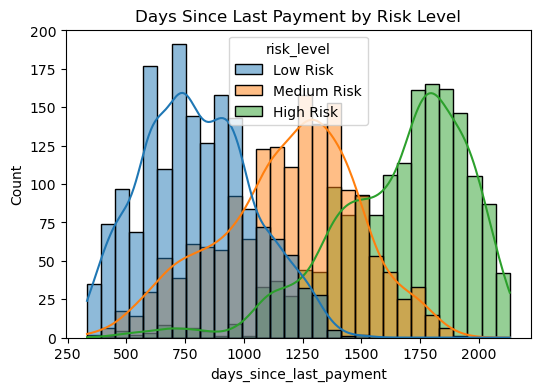

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(
    data=df,
    x="days_since_last_payment",
    hue="risk_level",
    bins=30,
    kde=True
)
plt.title("Days Since Last Payment by Risk Level")
plt.show()


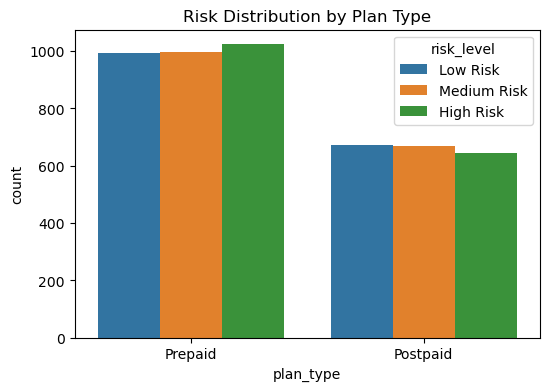

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="plan_type",
    hue="risk_level",
    data=df
)
plt.title("Risk Distribution by Plan Type")
plt.show()
